In [85]:
import numpy as np
import random
import seaborn as sns
from tqdm import tqdm

In [86]:
MIN_X = -32
MAX_X = 32

DIM = 30

NUM_POPULATION = 2000
NUM_ITERATIONS = 2000

INERTIA = 0.7
COMPONENT_COGNITIVE = 2
COMPONENT_SOCIAL = 2

In [87]:
def f(x: np.ndarray) -> float:
    assert x.shape == (DIM,)
    
    f_x = -20 * np.exp(-0.2 * np.sqrt(np.sum(x ** 2) / DIM)) - np.exp(np.sum(np.cos(2 * np.pi * x)) / DIM) + 20 + np.e
    if np.any(x < MIN_X) or np.any(x > MAX_X):
        return f_x + 2 * abs(f_x)
    
    return f_x

In [88]:
def compute_next_velocities(pop: np.array,
                            velocities: np.array,
                            best_individual: np.array,
                            best: np.array) -> np.array:
    r1 = random.random()
    r2 = random.random()

    component1 = INERTIA * velocities
    component2 = COMPONENT_COGNITIVE * r1 * (best_individual - pop)
    component3 = COMPONENT_SOCIAL * r2 * (best - pop)
    
    return component1 + component2 + component3

In [ ]:
pop = np.random.uniform(MIN_X, MAX_X + 1, (NUM_POPULATION, DIM))
best_individual = pop

velocities = np.random.uniform(-1, 1, (NUM_POPULATION, DIM)) # Small random initial velocities

best = None
best_f = None

best_history = []

with tqdm(iterable=range(NUM_ITERATIONS), desc="Iteration") as pbar:
    for gen in pbar:
        f_pop = np.apply_along_axis(func1d=f, arr=pop, axis=1)

        min_i = np.argmin(f_pop)
        curr_best = pop[min_i]
        curr_best_f = f_pop[min_i]

        if best_f is None or curr_best_f < best_f:
            best = curr_best
            best_f = curr_best_f
        best_history.append(best_f)

        # tqdm info
        pbar.set_postfix({
            'iter': gen + 1,
            'f_score': f'{best_f:.3f}'
        })

        next_velocities = compute_next_velocities(pop,
                                                  velocities,
                                                  best_individual,
                                                  best)
        velocities = next_velocities
        pop += velocities

Iteration: 100%|██████████| 2000/2000 [00:30<00:00, 64.54it/s, iter=2000, f_score=1.861]


In [90]:
print(round(best_f, 2))

1.86


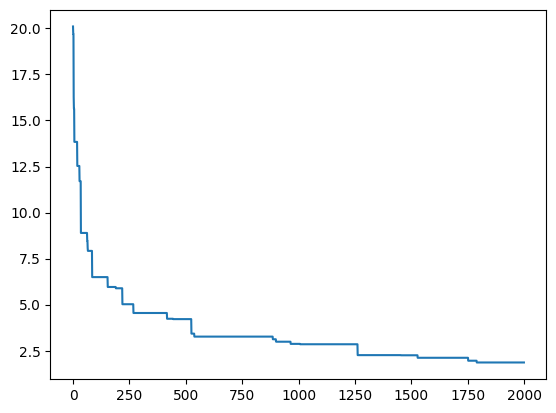

In [91]:
sns.lineplot(x=range(len(best_history)), y=best_history);